Task 1: Exploratory Data Analysis (EDA):
1.	Load the dataset and perform basic data exploration.
2.	Examine the distribution of features using histograms, box plots, or density plots.
3.	Investigate correlations between features to understand relationships within the data.


In [3]:
import pandas as pd 
df=pd.read_csv(r"C:\Users\vinod\Downloads\wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


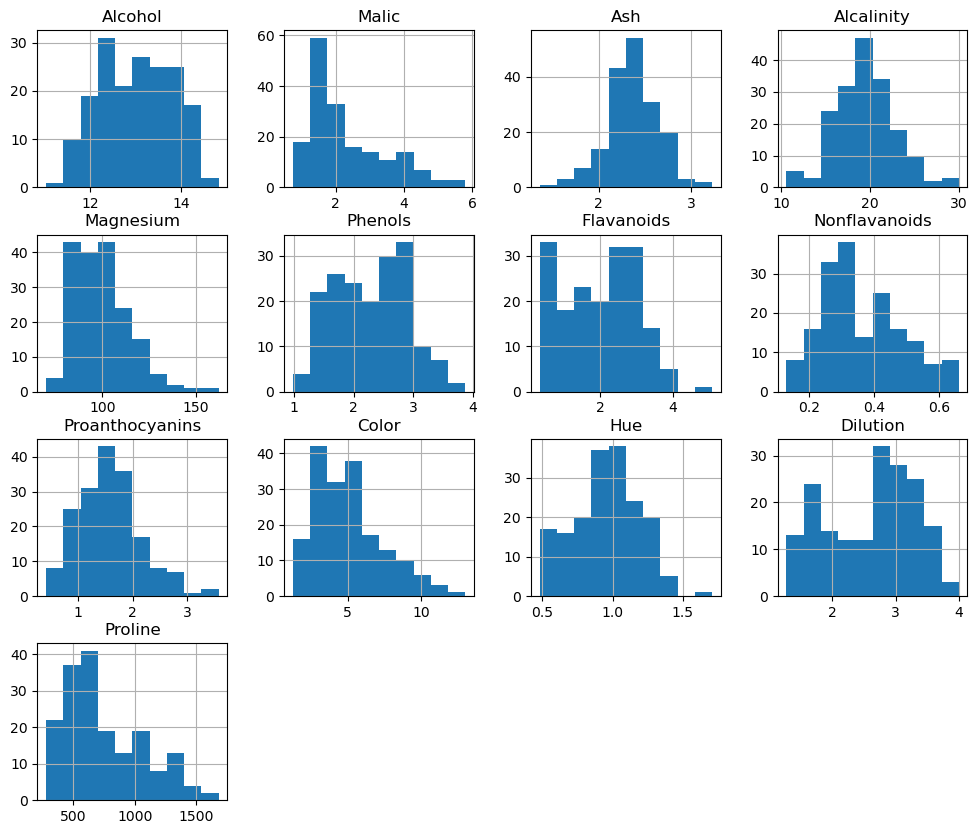

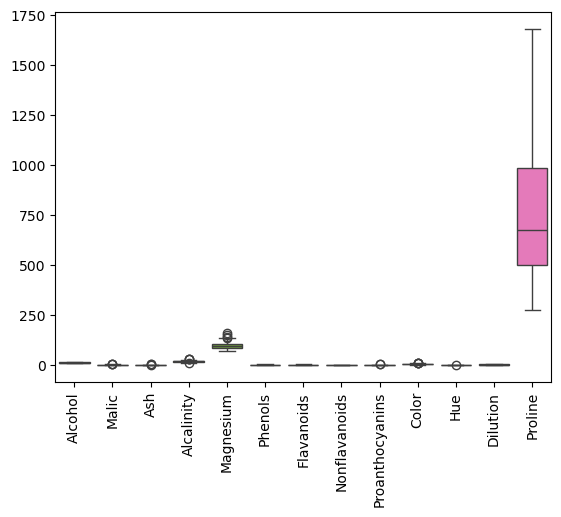

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df.drop("Type", axis=1).hist(figsize=(12,10))
plt.show()

sns.boxplot(data=df.drop("Type", axis=1))
plt.xticks(rotation=90)
plt.show()

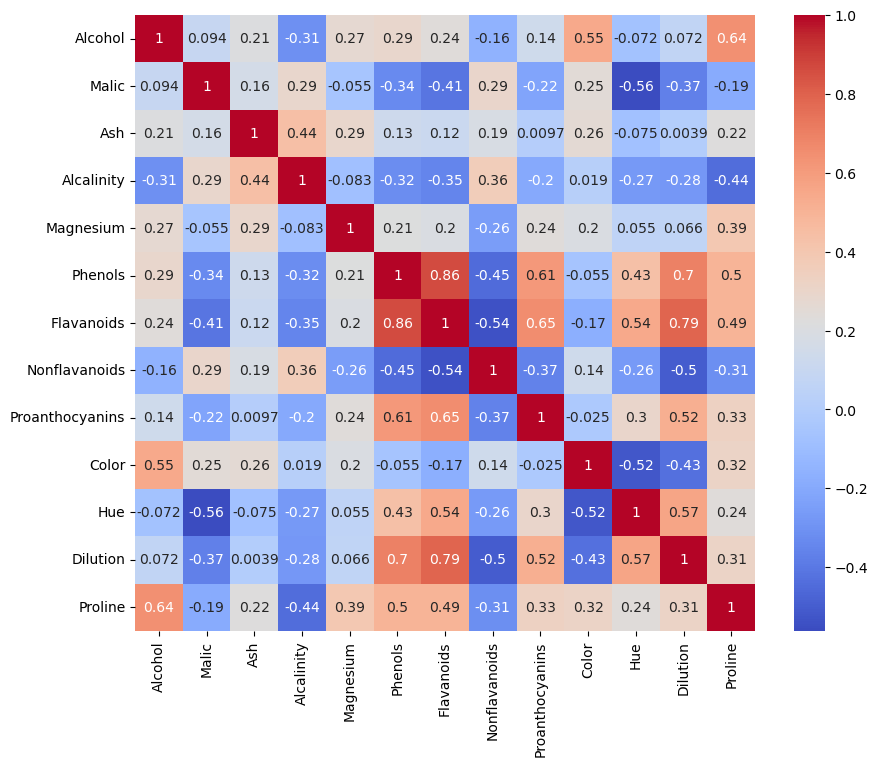

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop("Type", axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

Task 2: Dimensionality Reduction with PCA:
1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.
2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.
3.	Transform the original dataset into the principal components


In [8]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Type", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
from sklearn.decomposition import PCA

pca = PCA()
pca_data = pca.fit_transform(X_scaled)

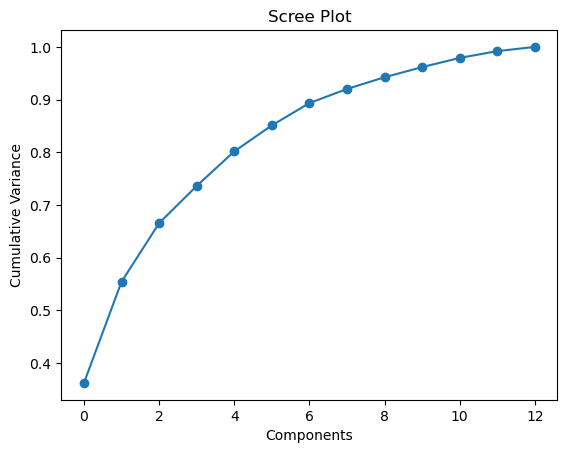

In [10]:
import numpy as np

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("Scree Plot")
plt.show()

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Task 3: Clustering with Original Data:
1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.
2.	Visualize the clustering results using appropriate plots.
3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index


In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

C:\Users\vinod\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


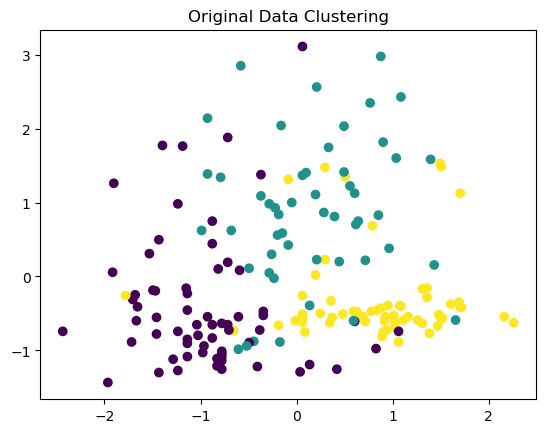

In [13]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')
plt.title("Original Data Clustering")
plt.show()

In [14]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Silhouette:", silhouette_score(X_scaled, labels))
print("DB Index:", davies_bouldin_score(X_scaled, labels))

Silhouette: 0.2848589191898987
DB Index: 1.389187977718165


Task 4: Clustering with PCA Data:
1.	Apply the same clustering algorithm to the PCA-transformed dataset.
2.	Visualize the clustering results obtained from PCA-transformed data.
3.	Compare the clustering results from PCA-transformed data with those from the original dataset.


In [15]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

C:\Users\vinod\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


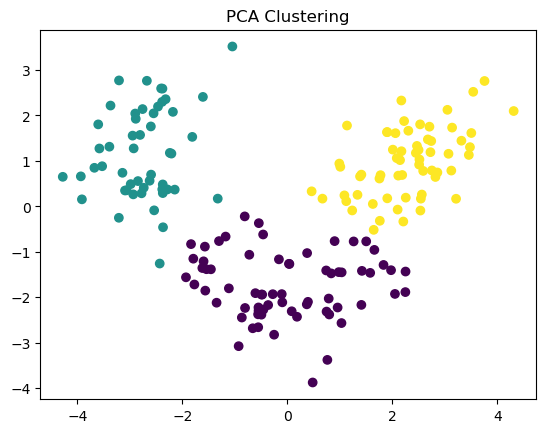

In [16]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca, cmap='viridis')
plt.title("PCA Clustering")
plt.show()

In [17]:
print("Silhouette (PCA):", silhouette_score(X_pca, labels_pca))
print("DB Index (PCA):", davies_bouldin_score(X_pca, labels_pca))

Silhouette (PCA): 0.5601697480957203
DB Index (PCA): 0.5977226208167409


Task 5: Comparison and Analysis:
1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.
2.	Discuss any similarities or differences observed in the clustering results.
3.	Reflect on the impact of dimensionality reduction on clustering performance.
4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.
Answer:
1.-> Comparison of Clustering Results

The clustering results obtained from the original dataset and the PCA-transformed dataset show noticeable differences. In the original dataset, clustering is performed on high-dimensional data, which may contain noise and redundant features. As a result, the clusters may not be very well separated.

On the other hand, clustering on the PCA-transformed dataset provides more distinct and well-separated clusters. This is because PCA reduces the dimensionality of the data while preserving the most important variance, making patterns easier to identify.

2.-->. Similarities and Differences

Similarities:

Both approaches aim to group similar data points into clusters.
The number of clusters remains the same in both cases (e.g., K = 3).

Differences:

The original dataset may produce overlapping clusters due to high dimensionality.
The PCA-transformed data results in clearer cluster boundaries.
PCA reduces noise and redundant features, improving clustering quality.

3.-->Impact of Dimensionality Reduction on Clustering

Dimensionality reduction using PCA has a significant impact on clustering performance. By reducing the number of features, PCA simplifies the dataset and removes less important information. This leads to:

Improved cluster separation
Faster computation
Better visualization (especially in 2D or 3D)

However, PCA may also lead to some loss of information, which can slightly affect clustering accuracy in certain cases.

4.-->Trade-offs Between PCA and Original Data Clustering

There are several trade-offs when choosing between clustering on the original dataset and PCA-transformed data:

PCA-Based Clustering	          Original Data Clustering
Reduces dimensionality	          Uses full feature set
Faster computation      	      More computationally expensive
Removes noise and redundancy      May include irrelevant features
Better visualization        	  Harder to visualize
Possible information loss	      Retains all information



Conclusion :
PCA effectively reduced dimensionality while retaining most of the variance
K-Means clustering performed better on PCA-transformed data
Visualization of clusters was clearer after PCA
However, slight loss of information was observed
PCA is recommended when working with high-dimensional datasets

final statement : Overall, PCA helps improve clustering performance by simplifying the dataset and highlighting important patterns.
    However, it is important to balance dimensionality reduction with potential information loss depending on the problem.
